# Computing for Economists: Dynamic Programming



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D

## Exercise: Optimal Portfolio Choice

In this exercise, we will walk solve an infinite-horizon, discrete-time optimal portfolio choice problem. At every period, the consumer decides how much to consume (given by $C$) and with their remaining wealth $(W-C)$, decides what fraction $\alpha$ to invest in a risky asset with stochastic returns $r_t$ vs. a risk-free asset with return $r_f$. The sequence problem is as follows:

$$\max_{\{\alpha_t\}, \{C_t\}} \sum_{t=0}^\infty \beta^t U(C_t) \text{ s.t. } $$
$$W_{t+1} = [\alpha_t (1+r_{t+1}) + (1-\alpha_t) (1+r_f)] (W_t - C_t)$$
$$r_{t+1} = (1-\rho) \mu + \rho r_t + \epsilon_t, \hspace{0.1cm} \epsilon_t \sim \mathcal{N}(0, \sigma^2)$$

1. <font color = '701B1B'> [Conceptual]</font> Re-write this problem using a recursive formulation (i.e. with the value function). What are the state and control variables?

***Solution:*** We have two state variables $(W_t, r_t)$ and two control variables $(\alpha_t, C_t)$. The Bellman equation is given by:

$$V(W, r) = \max_{\alpha, C} U(C) + \beta \int V(W', r') dP(r'|r) \text{ s.t. } $$
$$W' = [\alpha (1+r') + (1-\alpha) (1+r_f)] (W - C)$$
$$r' = \rho r + \epsilon, \hspace{0.1cm} \epsilon \sim \mathcal{N}(0, \sigma^2)$$


### Discretizing the State/Action Space

Since the state and action space are continuous, discretize the action and state space.

1. <font color='red'> [Write it yourself]</font> Create uniform grids for wealth, consumption, and investment fraction. Take maximum wealth to be 2. Think about what the grid boundaries should be.

In [ ]:
# Number of discrete states and actions
num_w_states = 50 # Number of discrete wealth states
num_alpha = 15  # Number of discrete actions for investment fraction
num_consumption = num_w_states   # Number of discrete consumption values

# Uniform grid of action and state space
W_max = 2

W_states = np.linspace(1e-6, W_max, num_w_states)
alpha_actions = np.linspace(0, 1, num_alpha)
C_actions = np.linspace(1e-6, W_max, num_consumption)

2. <font color = 'purple'> [AI Edit & Design Tests]</font> Now let's use Tauchen's method to discretize risky returns. Let $\mu = 7\%, \rho = 0.9, \sigma = 0.05$. The unconditional distribution of the AR(1) process is given by:

$$\mathcal{N}\left(\mu, \frac{\sigma^2}{1-\rho^2}\right)$$

Tauchen's method is described [here](https://web.archive.org/web/20190828155333/https://paulklein.se/newsite/teaching/Notes_DiscretizingAR1s.pdf). Write a test yourself to make sure the AI-generated code is correct.

Note: recall that in this problem, the grid and transition probabilities do not change over time. In Tauchen's method, to cover the full range of a stationary AR(1) process consider the range $\pm m \frac{\sigma}{\sqrt{1-\rho^2}}+\mu$ for some constant $m$.

In [ ]:
# Parameters for the return process
mu = 0.07 # Mean of risky returns (e.g. stock returns)
rho = 0.9    # Autoregressive parameter for risky returns
sigma = 0.05  # Standard deviation of shocks to risky returns

def tauchen(N, mu, rho, sigma, m=3):
    """
    Discretizes a stochastic process using Tauchen's method.

    Parameters:
    N (int): Number of discrete states.
    mu (float): Mean of the stochastic process.
    rho (float): Autoregressive parameter.
    sigma (float): Standard deviation of the shocks.
    m (float): Scaling parameter for the state space range.

    Returns:
    tuple: A tuple containing:
        - Z (numpy.ndarray): Discretized states.
        - P (numpy.ndarray): Transition probability matrix.
    """
    Z = np.linspace(-m * sigma / np.sqrt(1 - rho**2), m * sigma / np.sqrt(1 - rho**2), N)
    Z = Z + mu # Add the mean to the states
    Z_step = Z[1] - Z[0]
    P = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            loc = (1 - rho) * mu + rho * Z[i]
            if j == 0:
                P[i, j] = norm.cdf((Z[j] - loc + Z_step / 2) / sigma)
            elif j == N - 1:
                P[i, j] = 1 - norm.cdf((Z[j] - loc - Z_step / 2) / sigma)
            else:
                P[i, j] = (norm.cdf((Z[j] - loc + Z_step / 2) / sigma) -
                           norm.cdf((Z[j] - loc - Z_step / 2) / sigma))
    return Z, P

In [ ]:
# Unit test for Tauchen's method: iterating the transition matrix should converge to a unique
# stationary distribution, and for a correct discretization that distribution is the AR(1)'s
# unconditional N(mu, sigma**2 / (1 - rho**2)).
N = 20
Z_test, P_test = tauchen(N, mu, rho, sigma)

# (a) each row of the transition matrix is a valid probability distribution
assert np.allclose(P_test.sum(axis=1), 1.0)

# (b) iterating from any starting distribution converges to a single stationary distribution
dist = np.ones(N) / N                                   # start from a uniform distribution
for _ in range(1000):
    dist = dist @ P_test
assert np.allclose(dist @ P_test, dist, atol=1e-10)              # stationary: pi @ P == pi
assert np.allclose(np.linalg.matrix_power(P_test, 1000), dist)  # every row converges to pi

# (c) that stationary distribution matches the unconditional AR(1) distribution
uncond_sd = sigma / np.sqrt(1 - rho**2)
edges = np.concatenate([[-np.inf], (Z_test[:-1] + Z_test[1:]) / 2, [np.inf]])
unconditional = np.diff(norm.cdf(edges, loc=mu, scale=uncond_sd))
assert np.allclose(dist, unconditional, atol=1e-2)

print("Tauchen tests passed: valid transition matrix, converges to a unique stationary")
print("distribution, and that distribution matches the AR(1)'s unconditional distribution.")

Tauchen tests passed: valid transition matrix, converges to a unique stationary
distribution, and that distribution matches the AR(1)'s unconditional distribution.


<font color = 'orange'> [AI Edit & Human Review]</font> In class we discussed how we may want to form the grid such that areas with higher density have more grid points. Since we know the unconditional distribution of risky returns, allocate the grid points such that the probability density is uniformly distributed. For example, given 10 grid points, split the unconditional density into 10 areas with 10\% each. This will be a two-step process (first determine the grid points, then calculate the transition probability). Feel free to use either transition matrix you've computed.



In [ ]:
def endogenous_grid(N, mu, rho, sigma):
    """
    Creates grid for a stochastic process with equal probability between states.

    Parameters:
    N (int): Number of discrete states.
    mu (float): Mean of the stochastic process.
    rho (float): Autoregressive parameter.
    sigma (float): Standard deviation of the shocks.

    Returns:
    numpy.ndarray: Discretized states.
    """
    endpoints = np.zeros(N-1)
    Z = np.zeros(N)
    scale = sigma / np.sqrt(1 - rho**2)

    # Determining the grid points based on probability density
    for i in range(N-1):
        P = (1/N) * (i + 1)
        endpoints[i] = norm.ppf(P, loc = mu, scale = scale)
        if i == 0:
            Z[0] = endpoints[0]
        else:
            Z[i] = endpoints[i-1] + (endpoints[i] - endpoints[i-1])/2

    Z[-1] = endpoints[-1]

    return Z

def endogenous_transition(N, mu, rho, sigma):
    """
    Computes grid and transition probability matrix for a stochastic process.
    Grid is based on assuming equal probability between states.

    Parameters:
    N (int): Number of discrete states.
    mu (float): Mean of the stochastic process.
    rho (float): Autoregressive parameter.
    sigma (float): Standard deviation of the shocks.

    Returns:
    tuple: A tuple containing:
        - numpy.ndarray: Discretized states.
        - numpy.ndarray: Transition probability matrix.
    """
    Z = endogenous_grid(N, mu, rho, sigma)

    # Calculate transition matrix with grid
    P = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            loc = (1 - rho) * mu + rho * Z[i]
            if j == 0:
                P[i, j] = norm.cdf((Z[j] - loc) / sigma)
            elif j == N - 1:
                P[i, j] = 1 - norm.cdf((Z[j] - loc) / sigma)
            else:
                Z_stepf = Z[j+1] - Z[j]
                Z_stepb = Z[j] - Z[j-1]

                P[i, j] = (norm.cdf((Z[j] - loc + Z_stepf / 2) / sigma) -
                           norm.cdf((Z[j] - loc - Z_stepb / 2) / sigma))
    return Z, P

In [ ]:
num_r_states = 20  # Number of discrete states for risky returns
r_states, transition_matrix = endogenous_transition(num_r_states, mu, rho, sigma)

### Comparing Numerical Methods

Once you have discretized the state space of risky returns and calculated the transition matrix above, use each of the methods to solve the optimal porfolio choice problem:

*   Value Function Iteration (VFI)
*   Optimal Policy Iteration (OPI)

1. <font color='red'> [Write it yourself]</font> Assume CRRA utility $U(C) = \frac{C^{1-\gamma}}{1-\gamma}$ with $\gamma = 1$ (i.e. log utility) and a risk-free rate of $3.5\%$. For now, use a low $\beta$ (e.g. 0.6) to ensure quick convergence and feel free to test with higher $\beta$ with OPI (as you will see, VFI takes a long time). How many seconds and iterations does each method take? Save the final value and policy functions for plotting later.

Note: since we are discretizing continuous variables, feel free to using linear interpolation (check out [```numpy.interp```](https://numpy.org/doc/stable/reference/generated/numpy.interp.html)) to handle next period wealth falling outside the grid values.


In [ ]:
# Parameters
rf = 0.035    # Risk-free rate
gamma = 1   # Risk aversion

# Utility function
def utility(C, gamma):
    if gamma == 1:
        return np.log(C)
    else:
        return (C**(1 - gamma)) / (1 - gamma)

def wealth_transition(wealth, consumption, alpha, next_r, rf):
    next_wealth = (alpha * (1 + next_r) + (1 - alpha) * (1 + rf)) * (wealth - consumption)
    return np.maximum(next_wealth, 1e-10)  # Ensure non-negative wealth

In [ ]:
def solve_dp(wealth_states, consumption_actions, investment_actions, r_states,
             transition_matrix, utility, gamma, wealth_transition,
             method='VFI', V_init=None, beta=0.95, tol=1e-6, opi_iterations=5):
    """
    Solves the DP problem using specified method: VFI or OPI.

    Parameters:
    wealth_states (numpy.ndarray): Discretized wealth states.
    consumption_actions (numpy.ndarray): Discretized consumption actions.
    investment_actions (numpy.ndarray): Discretized investment actions.
    r_states (numpy.ndarray): Discretized states of risky asset returns.
    transition_matrix (numpy.ndarray): Transition probability matrix for risky returns.
    utility (function): Utility function.
    gamma (float): Risk aversion coefficient.
    wealth_transition (function): Transition function for wealth.
    method (str, optional): Method to use ('VFI' or 'OPI'). Defaults to 'VFI'.
    V_init (numpy.ndarray, optional): Initial value function guess. Defaults to None.
    beta (float, optional): Discount factor. Defaults to 0.95.
    tol (float, optional): Tolerance for convergence. Defaults to 1e-6.
    opi_iterations (int, optional): Number of value function iterations to perform within each policy iteration for OPI. Defaults to 5.

    Returns:
    tuple: A tuple containing:
        - V (numpy.ndarray): Optimal value function.
        - policy (numpy.ndarray): Optimal policy for consumption and investment.
    """
    if method not in ['VFI', 'OPI']:
        print("Invalid method. Choose 'VFI' or 'OPI'.")
        return None

    # Given value function, compute the value of taking a given action in a given state
    def compute_value_action(W, C, alpha, j, V):
        next_wealth = wealth_transition(W, C, alpha, r_states, rf)
        interpolated_value = np.array([np.interp(next_wealth[k], wealth_states, V[:, k]) for k in range(len(r_states))])
        expected_value = transition_matrix[j, :] @ interpolated_value
        total_value = utility(C, gamma) + beta * expected_value
        return total_value

    # Solve the Bellman equation using brute force to find optimal policy
    def update_value_function(V):
        V_new = np.zeros_like(V)
        policy = np.zeros((len(wealth_states), len(r_states), 2))  # For storing optimal consumption and investment

        for i, W in enumerate(wealth_states):
            for j, r in enumerate(r_states):
                value_action = np.full((len(consumption_actions), len(investment_actions)), -np.inf)
                for a_idx, alpha in enumerate(investment_actions):
                    for c_idx, C in enumerate(consumption_actions):
                        if C <= W:  # Ensure feasible consumption
                            value = compute_value_action(W, C, alpha, j, V)
                            value_action[c_idx, a_idx] = value

                best_action_idx = np.unravel_index(np.argmax(value_action), value_action.shape)
                best_c_idx, best_a_idx = best_action_idx

                V_new[i, j] = value_action[best_c_idx, best_a_idx]
                policy[i, j] = [consumption_actions[best_c_idx], investment_actions[best_a_idx]]
        return V_new, policy

    err = 100
    iter = 0

    if V_init is not None:
        V = V_init
    else:
        V = np.zeros((len(wealth_states), len(r_states)))

    while err > tol:
        V_new, policy = update_value_function(V)

        if method == 'OPI':
            for _ in range(opi_iterations):
                for i, W in enumerate(wealth_states):
                    for j, r in enumerate(r_states):
                        C, alpha = policy[i, j]
                        V_new[i, j] = compute_value_action(W, C, alpha, j, V_new)

        iter += 1
        err = np.max(np.abs(V - V_new))
        print(f"Iteration {iter} error {err}")
        V = V_new

    print(f"Converged after {iter} iterations.")
    return V, policy

2. <font color = '701B1B'> [Conceptual]</font> Why might pure HPI be difficult in this setting? What about linear programming?


***Solution:*** Since we are dealing with two states and two actions, the inversion step is more difficult when using policy function iteration. Though with OPI we will see that it is very fast, much more so than VFI. I don't try VFI with $\beta = 0.9$ because it takes too long. For similar state space reasons, linear programming will also take a long time due to the large number of constraints (one inequality constraint for every combination of state and action space).

3. <font color = 'orange'> [AI Edit & Human Review]</font> Use $\beta = 0.9$ and create 3D plots of the value function, optimal consumption, and optimal investment against the two state variables. Comment on the plots. Section IV of [Levhari and Srinivasan (1969)](https://econpapers.repec.org/article/ouprestud/v_3a36_3ay_3a1969_3ai_3a2_3ap_3a153-163..htm) may be of interest. Remember, do not be frazzled by a negative value function, it's about the relative levels (and with log utility, anything below one will generate negative utility).

<font color = 'orange'> [AI Edit & Human Review]</font> Depending on how fast your OPI is, feel free to adjust the risk aversion parameter $\gamma$, the discount factor $\beta$, and even the risky return parameters $\mu$ and $\sigma$ to see how that affects the optimal policy.

In [ ]:
V_opi_high_beta, policy_opi_high_beta = solve_dp(W_states, C_actions, alpha_actions, r_states, transition_matrix,
                                                 utility, gamma, wealth_transition, beta=0.9, method='OPI')


Iteration 1 error 86.11289823232629
Iteration 2 error 29.325790230461863
Iteration 3 error 35.076366577239114
Iteration 4 error 10.859417833863297
Iteration 5 error 3.886126003274743
Iteration 6 error 0.937858463339559
Iteration 7 error 0.2760017494785991
Iteration 8 error 0.06441191329460239
Iteration 9 error 0.015903965127286313
Iteration 10 error 0.0038741050287995904
Iteration 11 error 0.0010833918340011905
Iteration 12 error 0.00034588828748383094
Iteration 13 error 0.00011042973528674338
Iteration 14 error 3.525625476186178e-05
Iteration 15 error 1.1256057760533622e-05
Iteration 16 error 3.5936555349280752e-06
Iteration 17 error 1.1473253493932134e-06
Iteration 18 error 3.6629982957947504e-07
Converged after 18 iterations.


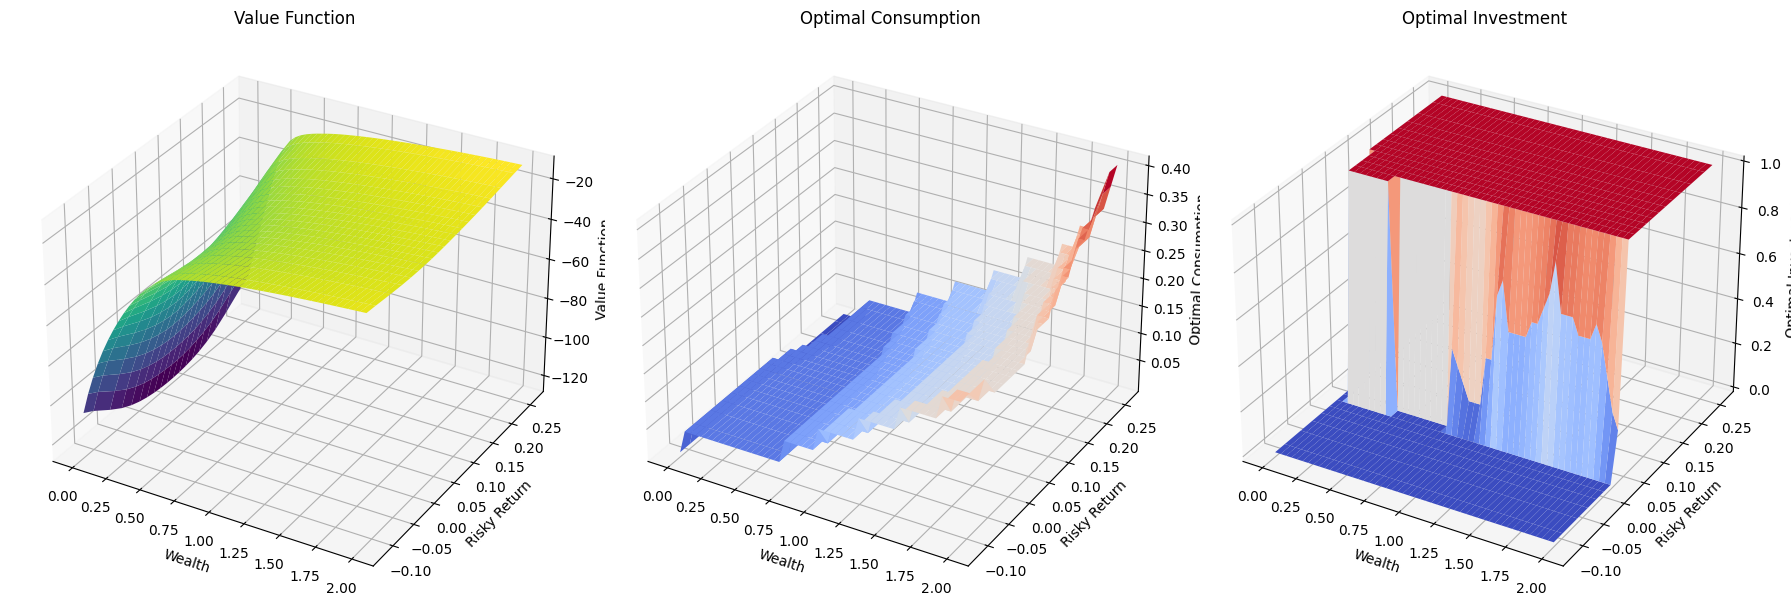

In [ ]:
def plot_dp_solution(policy_function, value_function, W_states, r_states):
    # Extract optimal consumption and investment from policy
    optimal_consumption = policy_function[:, :, 0]
    optimal_investment = policy_function[:, :, 1]

    # Prepare the meshgrid
    W, R = np.meshgrid(W_states, r_states)

    # Transpose V_discrete and policies if necessary to match the shape of the meshgrid
    V_discrete = value_function.T
    optimal_consumption = optimal_consumption.T
    optimal_investment = optimal_investment.T

    # Create a figure with three subplots
    fig = plt.figure(figsize=(18, 6))

    # Plot the value function
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.plot_surface(W, R, V_discrete, cmap='viridis')
    ax1.set_xlabel('Wealth')
    ax1.set_ylabel('Risky Return')
    ax1.set_zlabel('Value Function')
    ax1.set_title('Value Function')

    # Plot optimal consumption
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.plot_surface(W, R, optimal_consumption, cmap='coolwarm')
    ax2.set_xlabel('Wealth')
    ax2.set_ylabel('Risky Return')
    ax2.set_zlabel('Optimal Consumption')
    ax2.set_title('Optimal Consumption')

    # Plot optimal investment
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.plot_surface(W, R, optimal_investment, cmap='coolwarm')
    ax3.set_xlabel('Wealth')
    ax3.set_ylabel('Risky Return')
    ax3.set_zlabel('Optimal Investment')
    ax3.set_title('Optimal Investment')

    plt.tight_layout()
    plt.show()

plot_dp_solution(policy_opi_high_beta, V_opi_high_beta, W_states, r_states)

***Solution:*** With CRRA utility, we have a concave value function. For the same level of wealth, agents consume more when the risky return is higher. Furthermore, conditional on wealth, agents invest either all or nothing in the risky asset with an interior solution at a borderline return. Since agents are risk-averse, investment in the risky asset will only occur when the expected return exceeds that of the risk-free asset. With finer grid discretization of risky returns, there should be more interior solutions. The boundary also varies with different levels of risk aversion $\gamma$ (i.e. more risk averse agents will require a higher return and may invest less).

According to Levhari and Srinivasan (1969), they find that the optimal investment is either all or nothing, with an interior solution if the derivative of consumption fraction of wealth w.r.t. $\alpha$ is at zero. Equation (8) of [this handout](https://www.econ2.jhu.edu/people/ccarroll/public/lecturenotes/AssetPricing/Portfolio-CRRA.pdf) also highlights the factors that control share invested in the risky asset with a rule-of-thumb approximation since the problem is not exactly the same.

### Approximation Methods

Now we will estimate the value function via approximation. Since multidimensional approximation becomes much more difficult, we will alter the problem to a single state and control variable by removing the risky asset to get the classic optimal savings problem:

$$\max_{\{C_t\}} \sum_{t=0}^\infty \beta^t U(C_t) \text{ s.t. } $$
$$W_{t+1} = (1+r_f) (W_t - C_t)$$

This is a well-defined problem with an analytic solution. We know the form of the value function is log-linear for the case where $\gamma=1$, so that $U(C) = log(C)$:

$$V(W) = \phi + \psi log(W)$$

We have that $\psi = (1-\beta)^{-1}$ and $C^* = \frac{W}{1+\beta \psi}$, which we substitute into the Bellman equation and solve for $\phi$ by collecting similar terms. It turns out that:
$$\phi = \frac{1}{1-\beta}[log(1-\beta) + \beta \psi log((1+r_f)\beta]$$

1. <font color='red'> [Write it yourself]</font> Write functions that return the analytical value and policy functions.

<font color = 'purple'> [AI Edit & Design Tests]</font> Using the Bellman equation, have AI derive $\psi$ and $C^*$ analytically. The derivation is similar to the optimal consumption problem in ECON 2010C. How can you verify that the AI's analytic solution is correct?


In [ ]:
def value_analytical(W, beta, r_f):
    psi = 1 / (1 - beta)
    phi = 1 / (1 - beta) * (np.log(1 - beta) + beta * psi * np.log((1 + r_f) * beta))
    return phi + psi * np.log(np.maximum(W, 1e-10))

def policy_analytical(W, beta):
    return (1 - beta) * W

***Solution:*** Let $R_f = 1 + r_f$. Rearrange the Bellman equation to gather $\phi$ on the LHS:
$$(1-\beta) \phi + \psi log(W) = \max_{C \leq W} log(C) + \beta \psi log(R_f(W-C))$$

Take the FOC w.r.t. consumption and solve for $C^*$:
$$\frac{1}{C^*} + \frac{\beta \psi (-R_f)}{R_f(W-C^*)} = 0 \Rightarrow C^* = \frac{W}{1+\beta \psi}$$

Using the envelope theorem, take the derivative of the Bellman equation w.r.t. wealth at $C^*$ and solve for $C^*$:
$$\frac{\psi}{W} = \frac{\beta \psi R_f}{R_f(W-C^*)} \Rightarrow C^* = (1-\beta)W$$

Equate the two and solve for $\psi$. Then substitute both terms into the Bellman equation and collect all terms that do not contain $W$ to get $\phi$.

2. <font color='red'> [Write it yourself]</font> Now let's perform VFI with parametric aproximation (of two parameters). At each step, compute the (1) log-linear coefficients and (2) optimal policy using numerical optimization. Code has been provided for estimating the coefficients of the value function and the objective function to compute the optimal policy.


In [ ]:
def least_squares(coeffs, V_grid, W_grid):
    """
    Calculates the least squares difference between the actual value function and the approximated value function.

    Parameters:
    coeffs (array-like): Coefficients [phi, psi] for the log-linear value function.
    V_grid (array-like): The actual value function values on the grid of wealth states.
    W_grid (array-like): The grid of wealth states.

    Returns:
    float: The least squares difference between the actual value function and the approximated value function.
    """
    phi, psi = coeffs
    func_val = phi + psi * np.log(np.maximum(W_grid, 1e-10))
    return np.linalg.norm(func_val - V_grid)

In [ ]:
def solve_dp_approx(W_states, utility, wealth_transition, rf,
                    V_init=None, beta=0.95, tol=1e-6, gamma=1):
    """
    Solves a dynamic programming problem using an approximation method.

    Parameters:
    W_states (array-like): The grid of wealth states.
    utility (function): The utility function.
    wealth_transition (function): The wealth transition function.
    rf (float): The risk-free rate of return.
    V_init (array-like, optional): Initial guess for the value function. Defaults to None.
    beta (float, optional): The discount factor. Defaults to 0.95.
    tol (float, optional): The tolerance for convergence. Defaults to 1e-6.
    gamma (float, optional): The risk aversion parameter for the utility function. Defaults to 1.

    Returns:
    tuple: The approximated value function, the optimal policy function, and the coefficients [phi, psi].
    """
    if V_init is not None:
        V = V_init
    else:
        V = np.zeros(len(W_states))

    def bellman_operator(V, W_states, rf, coeffs_init):
        coeffs = opt.minimize(least_squares, coeffs_init, args=(V, W_states), method='L-BFGS-B', tol=1e-8).x

        def objective(C, W):
            if C <= 0 or C >= W:
                return -np.inf
            next_wealth = wealth_transition(W, C, 0, 0, rf) # No risky investment
            V_next = coeffs[0] + coeffs[1] * np.log(next_wealth)
            total_value = utility(C, gamma) + beta * V_next
            return -total_value  # Negative for minimization

        new_V = np.zeros(len(W_states))
        new_policy = np.zeros(len(W_states))
        for i, W in enumerate(W_states):
            initial_guess = W/2
            res = opt.minimize(objective, initial_guess, args=(W,), bounds=[(1e-10, W - 1e-10)], method='L-BFGS-B')
            if not res.success:
                print(f"Optimization failed at W={W}: {res.message}")
            new_V[i] = -res.fun
            new_policy[i] = res.x[0]
        return new_V, new_policy, coeffs

    err = 100
    iter = 0
    coeffs = [0, 0]
    while err > tol:
        V_new, policy, coeffs_new = bellman_operator(V, W_states, rf, coeffs)
        iter += 1
        err = np.max(np.abs(V - V_new))
        V = V_new
        coeffs = coeffs_new
    print(f"Converged after {iter} iterations.")
    return V, policy

3. <font color = 'orange'> [AI Edit & Human Review]</font> Plot the numerical value and policy functions against the analytical value and policy functions.

<font color = 'orange'> [AI Edit & Human Review]</font> Ask AI for some ways to improve the accuracy of the approximation. Do these seem feasible? Implement them if you have time.

***Solution:*** Students will find that increasing the number of grid points improves the approximation the most. For example, going from 50 to 500 points brings the coefficients significantly closer to the analytical solution. The tolerances of the inner loop can be tightened as well, but the approximation grid matters much more. However, the curse of dimensionality comes into play.

In [ ]:
beta=0.9
W_states = np.linspace(1e-6, W_max, 500)
V_approx, policy_approx = solve_dp_approx(W_states, utility, wealth_transition, rf, beta=beta)

Converged after 181 iterations.


In [ ]:
V_true = value_analytical(W_states, beta, rf)
policy_true = policy_analytical(W_states, beta)

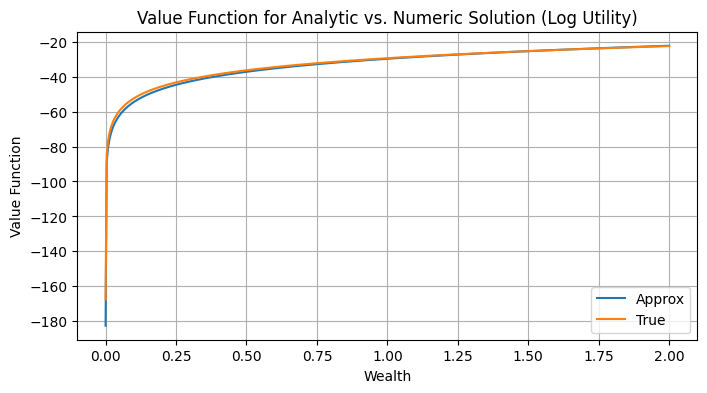

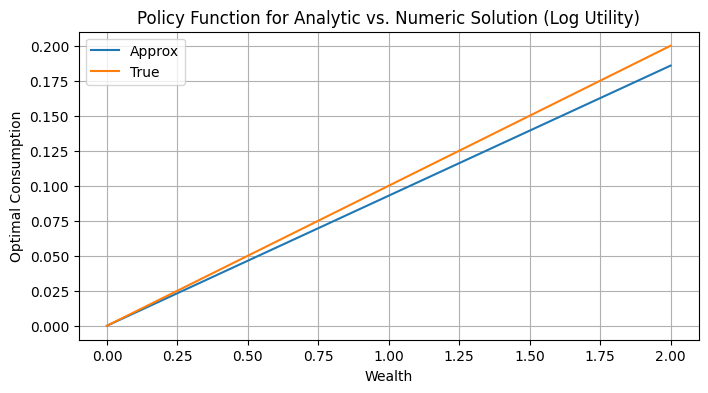

In [ ]:
# Plotting the value function for analytic vs numeric solution
plt.figure(figsize=(8, 4))
plt.plot(W_states, V_approx, label='Approx')
plt.plot(W_states, V_true, label='True')
plt.title('Value Function for Analytic vs. Numeric Solution (Log Utility)')
plt.xlabel('Wealth')
plt.ylabel('Value Function')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the policy function (optimal consumption) for different gamma values
plt.figure(figsize=(8, 4))
plt.plot(W_states, policy_approx, label='Approx')
plt.plot(W_states, policy_true, label='True')
plt.title('Policy Function for Analytic vs. Numeric Solution (Log Utility)')
plt.xlabel('Wealth')
plt.ylabel('Optimal Consumption')
plt.legend()
plt.grid(True)
plt.show()

4. <font color = '701B1B'> [Conceptual]</font> Why is smooth approximation and numerical optimization difficult for the original optimal portfolio allocation problem? Do you think there would be speed improvements?

***Solution:*** The multidimensional polynomial approximation is non-trivial in this problem. Furthermore, we will require numerical integration (e.g. quadrature) over the distribution of the AR(1) shocks. Also note that we have a multidimensional optimization problem that needs to be performed for all nodes of the state space, so there may not be substantial speed improvements. The optimization problem is quite ill-conditioned in this case if students were to try it out.

# Submission ⭐

Congratulations you finished this module! We will handle all exercise submissions on GitHub classroom. In order to access this assignment, you should already have a GitHub account with an associated repository unique to you. Please submit the assignment in that repository.